# Computer Vision — Lecture 1 Hands-On
### Images, tensors, channels, and colour spaces

**Goal:** by the end of this notebook you should be able to move an image between a file, a NumPy array
and a PyTorch tensor without losing track of its shape, dtype, value range, or channel order.

We use **torchvision** for image I/O and transforms, and **OpenCV** for the classical colour-space work.
Run each cell in order. Cells marked **TODO** are for you to complete.

---
## 0. Setup

Requires `torchvision >= 0.15` for the `transforms.v2` API.

In [1]:
# !pip install torch torchvision opencv-python matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision.io import read_image, write_png, ImageReadMode
from torchvision.transforms import v2 as T

import cv2

print("numpy      ", np.__version__)
print("torch      ", torch.__version__)
print("torchvision", torchvision.__version__)
print("opencv     ", cv2.__version__)
print("CUDA available:", torch.cuda.is_available())

numpy       2.3.4
torch       2.11.0+cpu
torchvision 0.26.0+cpu
opencv      4.13.0
CUDA available: False


### Get an image to work with

Put any JPEG/PNG next to this notebook and set `IMG_PATH`.
If no file is found, the cell downloads a sample; if that also fails (no internet in the lab),
it synthesises one so the rest of the notebook still runs.

In [2]:
import os, urllib.request

IMG_PATH = "Figs/cat.jpg"     # <-- change to your own image
SAMPLE_URL = ("https://upload.wikimedia.org/wikipedia/commons/thumb/4/4d/"
              "Cat_November_2010-1a.jpg?utm_source=en.wikipedia.org&utm_campaign=index&utm_content=original")

if not os.path.exists(IMG_PATH):
    try:
        urllib.request.urlretrieve(SAMPLE_URL, IMG_PATH)
        print("downloaded sample image")
    except Exception as e:
        print("download failed (%s) - synthesising an image instead" % type(e).__name__)
        h, w = 300, 400
        yy, xx = np.mgrid[0:h, 0:w]
        synth = np.stack([
            (255 * xx / w),                    # red   ramp left -> right
            (255 * yy / h),                    # green ramp top  -> bottom
            (128 + 127 * np.sin(xx / 25)),     # blue  stripes
        ]).astype(np.uint8)                    # note: already (C, H, W)
        write_png(torch.from_numpy(synth), IMG_PATH)

print("using:", IMG_PATH)

using: Figs/cat.jpg


---
## 1. Loading straight into a tensor

`read_image` decodes the file directly into a `uint8` tensor in **RGB** order and
**channel-first** `(C, H, W)` layout — the layout every PyTorch model expects.

shape (C,H,W): (3, 2397, 1795)
dtype        : torch.uint8
range        : 0 .. 255


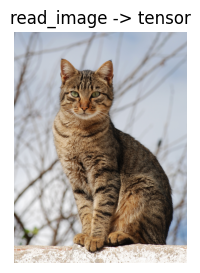

In [3]:
x_u8 = read_image(IMG_PATH, mode=ImageReadMode.RGB)   # force 3 channels (drops alpha)          # (C, H, W), uint8, RGB

C, H, W = x_u8.shape
print("shape (C,H,W):", tuple(x_u8.shape))
print("dtype        :", x_u8.dtype)
print("range        : %d .. %d" % (x_u8.min(), x_u8.max()))

def show(t, title="", ax=None, **kw):
    """Display a (C,H,W) tensor or an (H,W[,C]) array."""
    if isinstance(t, torch.Tensor):
        t = t.detach().cpu()
        if t.ndim == 3:
            t = t.permute(1, 2, 0)       # (C,H,W) -> (H,W,C) for matplotlib
        t = t.squeeze().numpy()
    ax = ax or plt.gca()
    ax.imshow(t, **kw); ax.set_title(title); ax.axis("off")

plt.figure(figsize=(4, 3)); show(x_u8, "read_image -> tensor"); plt.show()

Matplotlib wants `(H, W, C)`; PyTorch wants `(C, H, W)`. The `permute` inside `show`
is the bridge — you will write it hundreds of times this semester.

---
## 2. uint8 → float, and tensors ↔ NumPy

| Representation | Shape | dtype | Range |
|---|---|---|---|
| `read_image` output | `(C, H, W)` | `uint8` | 0–255 |
| after `ToDtype(..., scale=True)` | `(C, H, W)` | `float32` | 0.0–1.0 |
| NumPy for OpenCV | `(H, W, C)` | `uint8` | 0–255 |

In [4]:
to_float = T.ToDtype(torch.float32, scale=True)   # scale=True divides by 255
x = to_float(x_u8)

print("uint8  tensor: %-16s %-10s %3d .. %3d" % (tuple(x_u8.shape), x_u8.dtype, x_u8.min(), x_u8.max()))
print("float  tensor: %-16s %-10s %.2f .. %.2f" % (tuple(x.shape), x.dtype, x.min(), x.max()))

# Tensor -> NumPy (H, W, C) for OpenCV / matplotlib
arr = x_u8.permute(1, 2, 0).contiguous().numpy()
print("numpy  array : %-16s %-10s %3d .. %3d" % (arr.shape, arr.dtype, arr.min(), arr.max()))

# ... and back again
x_back = torch.from_numpy(arr).permute(2, 0, 1)
print("round-trip identical:", torch.equal(x_u8, x_back))

uint8  tensor: (3, 2397, 1795)  torch.uint8   0 .. 255
float  tensor: (3, 2397, 1795)  torch.float32 0.00 .. 1.00
numpy  array : (2397, 1795, 3)  uint8        0 .. 255
round-trip identical: True


**TODO 1.** Without running it first, predict the shape of `x.unsqueeze(0)`. Then check.

In [5]:
# TODO: your prediction here, then:
# print(x.unsqueeze(0).shape)

---
## 3. The three channels

A colour image is just three intensity maps stacked. Each one on its own is grayscale —
the colour below is added by the colour map, purely for readability.

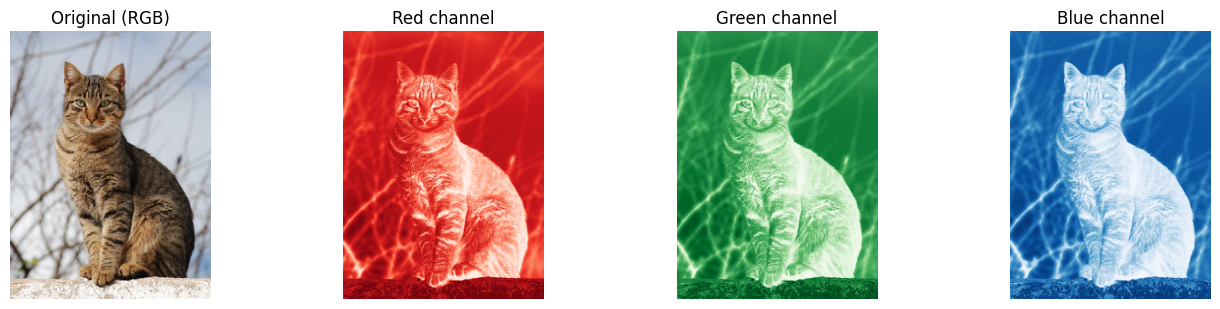

Red    mean 161.81  std  56.07
Green  mean 154.82  std  63.32
Blue   mean 150.03  std  73.37


In [6]:
names = ["Red", "Green", "Blue"]
cmaps = ["Reds", "Greens", "Blues"]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
show(x_u8, "Original (RGB)", axes[0])
for i in range(3):
    show(x_u8[i], "%s channel" % names[i], axes[i + 1], cmap=cmaps[i], vmin=0, vmax=255)
plt.tight_layout(); plt.show()

for i, n in enumerate(names):
    ch = x_u8[i].float()
    print("%-6s mean %6.2f  std %6.2f" % (n, ch.mean(), ch.std()))

---
## 4. Grayscale, three ways

The standard luminance formula is

$$Y = 0.299\,R + 0.587\,G + 0.114\,B$$

The weights are unequal because the eye is most sensitive to green and least to blue.
We compute it by hand and check it against torchvision and OpenCV.

manual vs torchvision  max abs diff: 1.025
manual vs OpenCV       max abs diff: 0.500
(differences below 1.0 are rounding to uint8, not a mistake)


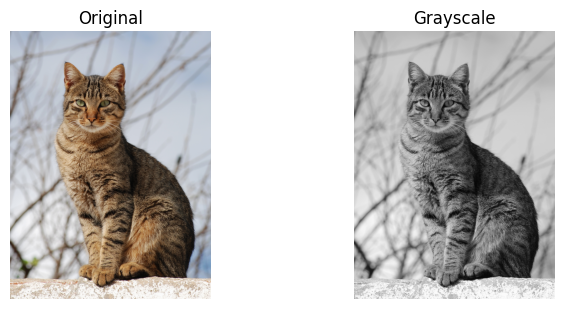

In [7]:
w = torch.tensor([0.299, 0.587, 0.114]).view(3, 1, 1)
gray_manual = (x_u8.float() * w).sum(dim=0)                    # (H, W) float

gray_tv = T.functional.rgb_to_grayscale(x_u8).squeeze(0).float()
gray_cv = torch.from_numpy(cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)).float()

print("manual vs torchvision  max abs diff: %.3f" % (gray_manual - gray_tv).abs().max())
print("manual vs OpenCV       max abs diff: %.3f" % (gray_manual - gray_cv).abs().max())
print("(differences below 1.0 are rounding to uint8, not a mistake)")

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
show(x_u8, "Original", axes[0])
show(gray_manual, "Grayscale", axes[1], cmap="gray")
plt.tight_layout(); plt.show()

**TODO 2.** Replace the weights with `1/3, 1/3, 1/3` (a plain average) and compare the two grayscale
images side by side. Where do they differ most, and why?

In [8]:
# TODO

---
## 5. Other colour spaces

Same pixels, different coordinate systems. Each makes a different property easy to reason about:

- **HSV** — separates *what colour* (hue) from *how bright* (value). Good for colour thresholding.
- **YCbCr** — separates luminance from chrominance. The basis of JPEG compression.
- **Lab** — approximately perceptually uniform: equal numeric distance ≈ equal perceived difference.

These conversions are one place where OpenCV is simply more convenient than PyTorch.

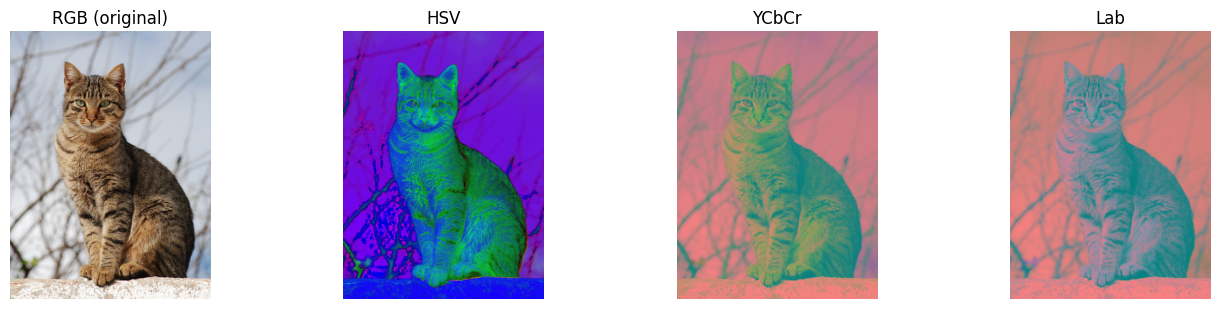

Displaying HSV/YCbCr/Lab arrays as if they were RGB is meaningless -
it is done here only to show that the numbers really are different.


In [9]:
hsv   = cv2.cvtColor(arr, cv2.COLOR_RGB2HSV)
ycbcr = cv2.cvtColor(arr, cv2.COLOR_RGB2YCrCb)
lab   = cv2.cvtColor(arr, cv2.COLOR_RGB2LAB)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, im, t in zip(axes, [arr, hsv, ycbcr, lab], ["RGB (original)", "HSV", "YCbCr", "Lab"]):
    show(im, t, ax)
plt.tight_layout(); plt.show()

print("Displaying HSV/YCbCr/Lab arrays as if they were RGB is meaningless -")
print("it is done here only to show that the numbers really are different.")

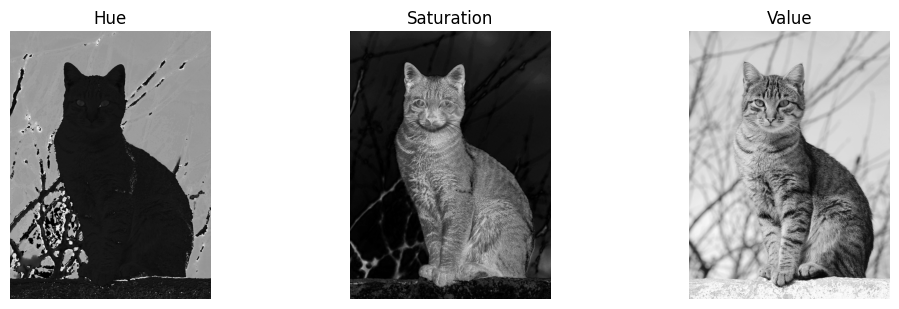

In [10]:
# The individual HSV channels, which DO mean something on their own
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, i, t in zip(axes, range(3), ["Hue", "Saturation", "Value"]):
    show(hsv[:, :, i], t, ax, cmap="gray")
plt.tight_layout(); plt.show()

---
## 6. The BGR bug — on purpose

`cv2.imread` returns channels in **BGR** order, while torchvision, matplotlib and every pretrained
model assume RGB. Let's reproduce the classic mistake so you recognise it when it happens to you at 2 a.m.

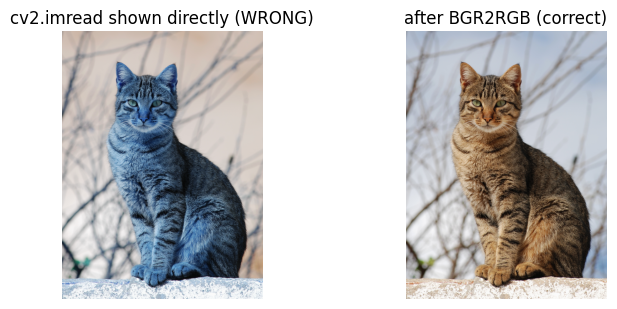

matches read_image after conversion: True


In [11]:
bgr = cv2.imread(IMG_PATH)                    # BGR!
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)    # fixed

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
show(bgr, "cv2.imread shown directly (WRONG)", axes[0])
show(rgb, "after BGR2RGB (correct)", axes[1])
plt.tight_layout(); plt.show()

print("matches read_image after conversion:", np.array_equal(rgb, arr))

---
## 7. The standard input pipeline

Almost every model in this course is fed by a pipeline of this shape:

`resize → crop → float → normalize`

The constants below are the ImageNet statistics; pretrained models expect them.

In [12]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

pipeline = T.Compose([
    T.Resize(256),                              # shorter side -> 256
    T.CenterCrop(224),                          # 224 x 224
    T.ToDtype(torch.float32, scale=True),       # -> [0, 1]
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

xt = pipeline(x_u8)
print("shape:", tuple(xt.shape))
print("mean per channel:", [round(float(v), 3) for v in xt.mean(dim=(1, 2))])
print("std  per channel:", [round(float(v), 3) for v in xt.std(dim=(1, 2))])
print("range: %.2f .. %.2f  (normalised data is NOT in [0,1])" % (xt.min(), xt.max()))

shape: (3, 224, 224)
mean per channel: [0.457, 0.402, 0.459]
std  per channel: [0.96, 1.114, 1.288]
range: -2.02 .. 2.50  (normalised data is NOT in [0,1])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.500567].


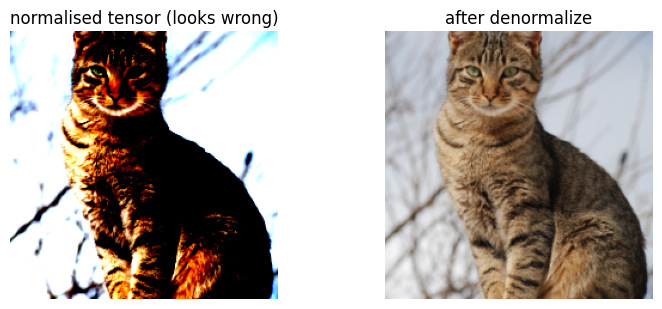

In [13]:
def denormalize(t, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Undo Normalize so the tensor can be displayed."""
    m = torch.tensor(mean).view(3, 1, 1)
    s = torch.tensor(std).view(3, 1, 1)
    return (t * s + m).clamp(0, 1)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
show(xt, "normalised tensor (looks wrong)", axes[0])
show(denormalize(xt), "after denormalize", axes[1])
plt.tight_layout(); plt.show()

### Batching

Models never see one image; they see a batch of shape `(N, C, H, W)`.

In [14]:
batch = torch.stack([pipeline(x_u8) for _ in range(8)])
print("batch shape:", tuple(batch.shape), "->  (N, C, H, W)")
print("memory: %.2f MB" % (batch.element_size() * batch.nelement() / 1e6))

batch shape: (8, 3, 224, 224) ->  (N, C, H, W)
memory: 4.82 MB


---
## 8. Exercises

1. **Shapes.** Write a function `describe(z)` that prints shape, dtype and value range for a NumPy array
   or a torch tensor — and works out which one it was given.
2. **Channel swap.** Swap the red and blue channels of `x_u8` using only tensor indexing.
   Confirm the result equals `cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)` after the layout change.
3. **Colour thresholding.** Using the HSV image, build a mask selecting only pixels whose hue is in a
   range you choose, and display the original with everything else set to black.
4. **Your own grayscale.** Which single RGB channel is closest to the true luminance image? Measure it.
5. **Resize order.** Compare `T.Resize(64)` then `T.Resize(224)` against `T.Resize(224)` alone.
   What was lost, and can you quantify it?

---
### Recap

| Representation | Shape | dtype | Range | Order |
|---|---|---|---|---|
| `read_image` | `(C, H, W)` | `uint8` | 0–255 | RGB |
| NumPy for OpenCV | `(H, W, C)` | `uint8` | 0–255 | **BGR** from `cv2.imread` |
| After transforms | `(C, H, W)` | `float32` | 0–1 | RGB |
| Batch | `(N, C, H, W)` | `float32` | normalised | RGB |

Next week: filtering, convolution and edge detection — all of it operating on exactly these arrays.